# TFM — Gastronomía asiática en Europa
## Semana 3: Preprocesamiento, feature engineering y primeros modelos

Objetivo: predecir `avg_rating` a partir de las características del restaurante.

- Limpieza de datos (nulos, outliers, encoding)
- Transformación de variables (feature engineering)
- División train/test
- Modelos iniciales: Regresión Lineal, Random Forest, XGBoost
- Comparativa de métricas (RMSE, MAE, R²)


## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 60)

RANDOM_STATE = 42

df = pd.read_csv('../data/asian_restaurants_europe.csv', low_memory=False)
print('Shape original:', df.shape)


Shape original: (86306, 42)


## 1. Limpieza de datos

### 1.1 Filtrar filas sin target
`avg_rating` es la variable a predecir: sin ella la fila no sirve para entrenar.

In [2]:
df = df.dropna(subset=['avg_rating']).copy()
print('Shape tras eliminar filas sin avg_rating:', df.shape)


Shape tras eliminar filas sin avg_rating: (81315, 42)


### 1.2 Descartar columnas no utilizables

Se excluyen tres tipos de columnas:

1. **Identificadores / texto libre sin procesar**: `restaurant_link`, `restaurant_name`, `original_location`,
   `address`, `original_open_hours`, `default_language`, `keywords`, `top_tags`, `awards`, `special_diets`,
   `features` — no aportan como features numéricas/categóricas directas (serían necesarias técnicas de NLP,
   fuera del alcance de esta primera versión del modelo).
2. **Fuga de información (data leakage)**: `excellent`, `very_good`, `average`, `poor`, `terrible` — son
   conteos derivados directamente de la distribución de `avg_rating` de cada restaurante, no características
   independientes. Usarlas sería "hacer trampa" (el modelo aprendería a leer el propio target).
3. **Muy alta proporción de nulos y poco valor incremental**: `province` (46%), `city` (25%, además de muy
   alta cardinalidad) — se mantiene `country` y `region` como nivel geográfico.

In [3]:
cols_identificadores = ['restaurant_link', 'restaurant_name', 'original_location', 'address',
                        'original_open_hours', 'default_language', 'keywords', 'top_tags',
                        'awards', 'special_diets', 'features']
cols_leakage = ['excellent', 'very_good', 'average', 'poor', 'terrible']
cols_descartadas_nulos = ['province', 'city']

df = df.drop(columns=cols_identificadores + cols_leakage + cols_descartadas_nulos)
print('Shape tras descartar columnas:', df.shape)
print(df.columns.tolist())


Shape tras descartar columnas: (81315, 24)
['country', 'region', 'latitude', 'longitude', 'claimed', 'popularity_detailed', 'popularity_generic', 'price_level', 'price_range', 'meals', 'cuisines', 'vegetarian_friendly', 'vegan_options', 'gluten_free', 'open_days_per_week', 'open_hours_per_week', 'working_shifts_per_week', 'avg_rating', 'total_reviews_count', 'reviews_count_in_default_language', 'food', 'service', 'value', 'atmosphere']


### 1.3 Revisar nulos restantes

In [4]:
nulos = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
nulos[nulos > 0]


atmosphere                 71.668204
price_range                67.991146
meals                      34.988624
open_days_per_week         34.104409
open_hours_per_week        34.104409
working_shifts_per_week    34.104409
value                      32.666790
service                    32.620058
food                       32.586854
price_level                14.304864
region                      7.055279
latitude                    0.811658
longitude                   0.811658
popularity_generic          0.091004
popularity_detailed         0.009838
dtype: float64

### 1.4 Outliers en `total_reviews_count`

Es una variable muy asimétrica (pocos restaurantes con miles de reseñas, la mayoría con pocas).
Se aplica `log1p` en vez de eliminar outliers, para no perder información.

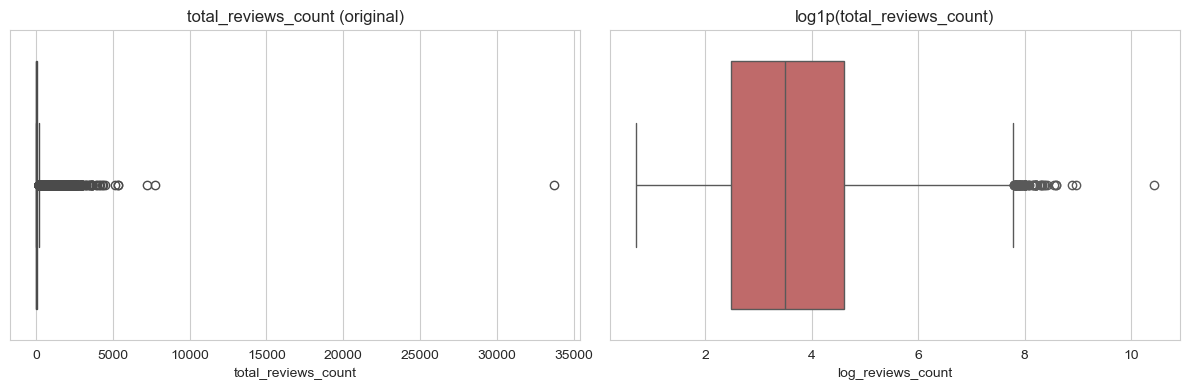

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df['total_reviews_count'], ax=axes[0], color='steelblue')
axes[0].set_title('total_reviews_count (original)')

df['log_reviews_count'] = np.log1p(df['total_reviews_count'])
sns.boxplot(x=df['log_reviews_count'], ax=axes[1], color='indianred')
axes[1].set_title('log1p(total_reviews_count)')
plt.tight_layout()
plt.savefig('../data/fig_outliers_reviews.png', dpi=100)
plt.show()


## 2. Feature engineering

### 2.1 Variables binarias simples (Y/N, Claimed/Unclaimed)

In [6]:
df['claimed_flag'] = (df['claimed'] == 'Claimed').astype(int)
df['vegetarian_flag'] = (df['vegetarian_friendly'] == 'Y').astype(int)
df['vegan_flag'] = (df['vegan_options'] == 'Y').astype(int)
df['gluten_free_flag'] = (df['gluten_free'] == 'Y').astype(int)

df = df.drop(columns=['claimed', 'vegetarian_friendly', 'vegan_options', 'gluten_free'])


### 2.2 `price_level` — codificación ordinal (nivel de precio creciente)

In [7]:
price_map = {'€': 1, '€€-€€€': 2, '€€€€': 3}
df['price_level_ord'] = df['price_level'].map(price_map)
df = df.drop(columns=['price_level', 'price_range'])

df['price_level_ord'].value_counts(dropna=False)


price_level_ord
2.0    49794
1.0    18228
NaN    11632
3.0     1661
Name: count, dtype: int64

### 2.3 `meals` — flags por tipo de servicio (Lunch, Dinner, Breakfast, Drinks...)

In [8]:
meal_types = ['Lunch', 'Dinner', 'Breakfast', 'Brunch', 'Drinks', 'After-hours']
for meal in meal_types:
    df[f'meal_{meal.lower().replace("-", "_")}'] = df['meals'].fillna('').str.contains(meal, case=False).astype(int)

df = df.drop(columns=['meals'])


### 2.4 `cuisines` — nº de cocinas ofrecidas y flags por tipo de cocina asiática

In [9]:
asian_cuisines = ['Chinese', 'Japanese', 'Thai', 'Korean',
                  'Vietnamese', 'Indian', 'Asian', 'Sushi',
                  'Dim Sum', 'Ramen', 'Noodles']

df['n_cuisines'] = df['cuisines'].fillna('').apply(lambda x: len([c for c in x.split(',') if c.strip()]))

for cuisine in asian_cuisines:
    col_name = 'cuisine_' + cuisine.lower().replace(' ', '_')
    df[col_name] = df['cuisines'].fillna('').str.contains(cuisine, case=False).astype(int)

df = df.drop(columns=['cuisines'])


### 2.5 `country` — agrupar países poco frecuentes en "Other"

Con muchas categorías raras el one-hot encoding generaría columnas casi vacías. Se mantienen los 15 países
más frecuentes y el resto se agrupa.

In [10]:
top_countries = df['country'].value_counts().head(15).index
df['country_grouped'] = df['country'].where(df['country'].isin(top_countries), 'Other')
df = df.drop(columns=['country'])

df['country_grouped'].value_counts()


country_grouped
England            22914
France             12676
Germany             8836
Spain               7758
Italy               6984
Other               3907
The Netherlands     3562
Sweden              2312
Belgium             2146
Scotland            2101
Portugal            1665
Poland              1586
Ireland             1365
Austria             1252
Wales               1231
Denmark             1020
Name: count, dtype: int64

### 2.6 Imputar nulos restantes en variables numéricas clave

In [11]:
nulos_restantes = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
nulos_restantes[nulos_restantes > 0]


atmosphere                 71.668204
open_days_per_week         34.104409
open_hours_per_week        34.104409
working_shifts_per_week    34.104409
value                      32.666790
service                    32.620058
food                       32.586854
price_level_ord            14.304864
region                      7.055279
longitude                   0.811658
latitude                    0.811658
popularity_generic          0.091004
popularity_detailed         0.009838
dtype: float64

`food`, `service`, `value`, `atmosphere` son sub-puntuaciones de TripAdvisor (distintas de `avg_rating`,
no leakage) pero tienen bastantes nulos. Se imputan más adelante dentro del pipeline con la mediana,
junto con el resto de numéricas, para evitar fugas de información entre train y test.

**Nota sobre `popularity_generic` y `popularity_detailed`:** se excluyen deliberadamente como features.
`popularity_generic` resultó ser prácticamente un identificador de texto único por restaurante
(p. ej. `"#5907 of 18480 places to eat in Paris"`, con más de 81.000 valores distintos para 81.315 filas):
incluirlo en un one-hot generaba ~81.000 columnas dummy y desestabilizaba por completo la Regresión Lineal
(R² negativo). Además, el ranking de TripAdvisor se calcula a partir del propio rating y del volumen de
reseñas, por lo que usarlo como feature sería también una forma de data leakage.

## 3. Train / test split

In [12]:
target = 'avg_rating'

numeric_features = ['log_reviews_count', 'food', 'service', 'value', 'atmosphere',
                    'open_days_per_week', 'open_hours_per_week', 'working_shifts_per_week',
                    'latitude', 'longitude', 'price_level_ord', 'n_cuisines']

binary_features = ['claimed_flag', 'vegetarian_flag', 'vegan_flag', 'gluten_free_flag'] + \
    [c for c in df.columns if c.startswith('meal_')] + \
    [c for c in df.columns if c.startswith('cuisine_')]

categorical_features = ['country_grouped', 'region']

feature_cols = numeric_features + binary_features + categorical_features

X = df[feature_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print('Train:', X_train.shape, ' Test:', X_test.shape)


Train: (65052, 35)  Test: (16263, 35)


## 4. Pipeline de preprocesamiento

- Numéricas: imputación por mediana + escalado estándar
- Binarias: imputación por 0 (ausencia de información = no marcado)
- Categóricas: imputación por moda + one-hot encoding

El `ColumnTransformer` se ajusta **solo con train** y se aplica a test, evitando data leakage.

In [13]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('bin', binary_transformer, binary_features),
    ('cat', categorical_transformer, categorical_features),
])


## 5. Entrenar modelos iniciales

Se comparan cuatro modelos, todos vistos y practicados con código durante el máster:

- **Regresión Lineal** y **Random Forest** — módulo de Minería de Datos / Árboles y sus extensiones (Javier Castro).
- **XGBoost** — módulo de Árboles y sus extensiones (Javier Castro).
- **SVR (Support Vector Regression)** — módulo de Machine Learning (Inmaculada Gutiérrez); es la versión de regresión del SVM que en la tarea de esa asignatura resultó ser el modelo ganador (kernel RBF).

In [14]:
models = {
    'Regresión Lineal': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1,
                            objective='reg:squarederror'),
}

results = []
fitted_pipelines = {}

for name, model in models.items():
    # clone(preprocessor): cada Pipeline necesita su propia instancia ajustada. Si se reutilizase
    # el mismo objeto `preprocessor` en las cuatro Pipelines, cada .fit() posterior sobrescribiría
    # el estado interno (categorías del OneHotEncoder, medianas del imputer...) de las anteriores.
    pipe = Pipeline(steps=[('preprocessor', clone(preprocessor)), ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({'Modelo': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2})
    fitted_pipelines[name] = pipe
    print(f'{name:20s} RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}')


Regresión Lineal     RMSE=0.5476  MAE=0.3748  R2=0.3722


Random Forest        RMSE=0.5575  MAE=0.3649  R2=0.3494


XGBoost              RMSE=0.5482  MAE=0.3625  R2=0.3709


### 5.1 SVR — entrenado sobre una submuestra

Un SVR con kernel RBF tiene coste computacional cuadrático/cúbico en el número de muestras: con
~65.000 filas de entrenamiento sería intratable en tiempo razonable (igual que en la asignatura de
Machine Learning, donde el dataset de la tarea tenía solo ~9.200 filas). Se entrena sobre una
submuestra aleatoria de 8.000 filas del train, pero se **evalúa sobre todo el conjunto de test**
para que la comparación con el resto de modelos sea justa.

In [15]:
SVR_SAMPLE_SIZE = 8000

X_train_svr = X_train.sample(n=SVR_SAMPLE_SIZE, random_state=RANDOM_STATE)
y_train_svr = y_train.loc[X_train_svr.index]

svr_pipe = Pipeline(steps=[
    ('preprocessor', clone(preprocessor)),
    ('model', SVR(kernel='rbf', C=1.0, gamma='scale')),
])
svr_pipe.fit(X_train_svr, y_train_svr)
y_pred_svr = svr_pipe.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_svr))
mae = mean_absolute_error(y_test, y_pred_svr)
r2 = r2_score(y_test, y_pred_svr)

results.append({'Modelo': 'SVR', 'RMSE': rmse, 'MAE': mae, 'R2': r2})
fitted_pipelines['SVR'] = svr_pipe
print(f'{"SVR":20s} RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}  (train n={SVR_SAMPLE_SIZE})')


SVR                  RMSE=0.5599  MAE=0.3682  R2=0.3437  (train n=8000)


### 5.2 Red densa (Keras) — resultado del notebook `03b_red_densa_keras.ipynb`

El quinto modelo (MLP/red densa, módulo de Deep Learning) se entrena en un **notebook aparte**
(`03b_red_densa_keras.ipynb`), ejecutado con un kernel de Python distinto (entorno virtual `tfm-tf`).

**Motivo:** TensorFlow provocó un `segmentation fault` al importarse en el entorno base de Anaconda
usado en el resto del TFM, por un conflicto de versión de `protobuf` con otros paquetes ya instalados
en ese entorno (p. ej. streamlit). Para no arriesgar la estabilidad del entorno principal (usado en
todas las demás semanas del TFM), se creó un entorno virtual aislado solo para TensorFlow. Ambos
notebooks parten de la misma división train/test (`random_state=42`) y las mismas features, por lo
que los resultados son directamente comparables.

Aquí se cargan sus métricas ya calculadas para incorporarlas a la tabla comparativa.

In [16]:
import json
import os

dense_nn_path = '../data/dense_nn_metrics.json'

if os.path.exists(dense_nn_path):
    with open(dense_nn_path) as f:
        dense_nn_metrics = json.load(f)
    results.append({'Modelo': 'Red densa (Keras)', **dense_nn_metrics})
    print('Red densa (Keras)   RMSE={RMSE:.4f}  MAE={MAE:.4f}  R2={R2:.4f}'.format(**dense_nn_metrics))
else:
    print('Aviso: no se encontró ../data/dense_nn_metrics.json — ejecuta antes 03b_red_densa_keras.ipynb')


Red densa (Keras)   RMSE=0.5404  MAE=0.3618  R2=0.3886


## 6. Comparativa de métricas

In [17]:
results_df = pd.DataFrame(results).set_index('Modelo')
results_df


,RMSE,MAE,R2
Modelo,,,
Regresión Lineal,0.547628,0.374824,0.372217
Random Forest,0.557491,0.364927,0.349399
XGBoost,0.548191,0.362514,0.370925
SVR,0.559915,0.368194,0.343730
Red densa (Keras),0.540440,0.361837,0.388589


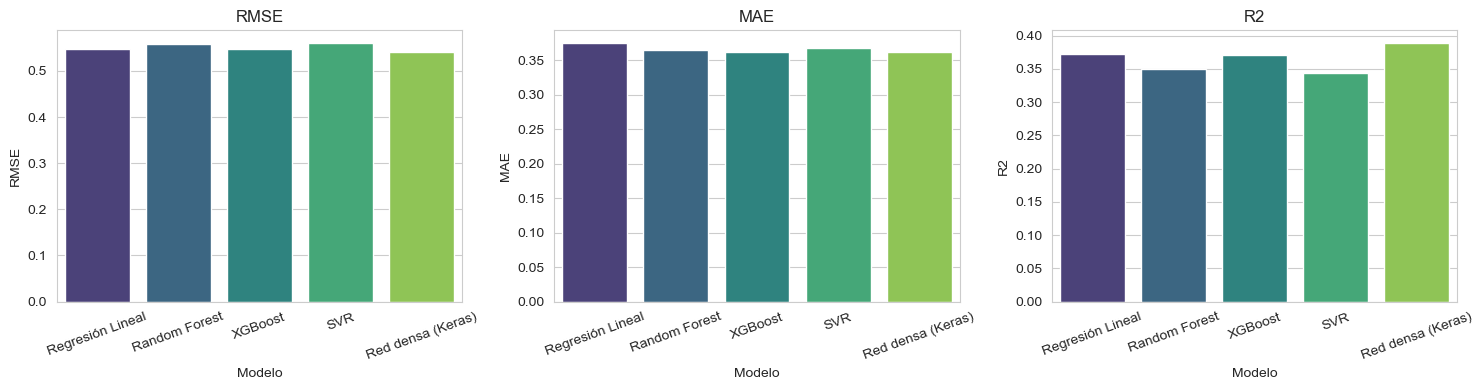

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['RMSE', 'MAE', 'R2']):
    sns.barplot(x=results_df.index, y=results_df[metric], hue=results_df.index,
                palette='viridis', legend=False, ax=ax)
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('../data/fig_comparativa_modelos.png', dpi=100)
plt.show()


Mejor modelo por RMSE: Red densa (Keras)
"Red densa (Keras)" no tiene un Pipeline de sklearn en este notebook (se entrena aparte). Se usa el mejor modelo con Pipeline disponible para la gráfica de importancia.


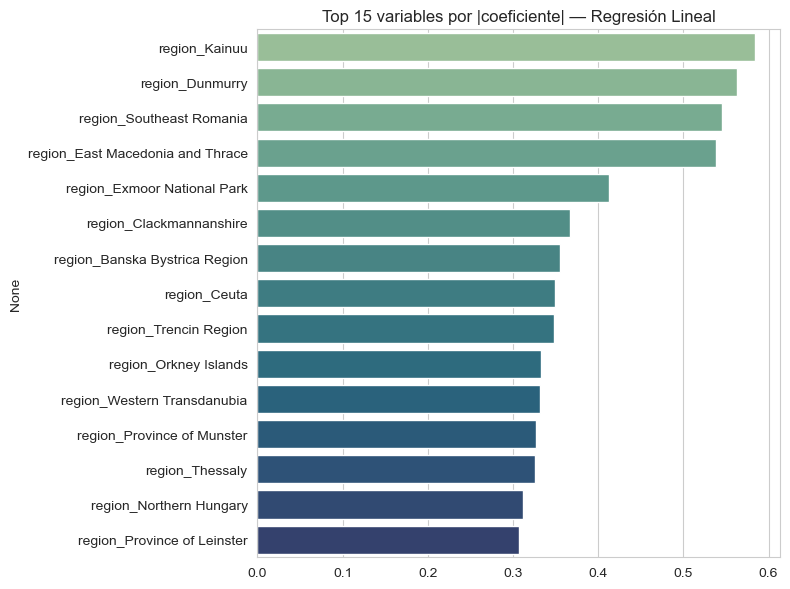

In [19]:
best_model_name = results_df['RMSE'].idxmin()
print(f'Mejor modelo por RMSE: {best_model_name}')

if best_model_name not in fitted_pipelines:
    # La red densa (Keras) se entrena en otro notebook/entorno y no tiene un Pipeline de sklearn
    # aquí, así que no se le puede sacar feature_importances_. Se usa el mejor modelo CON pipeline
    # disponible solo para esta gráfica de importancia de variables.
    print(f'\"{best_model_name}\" no tiene un Pipeline de sklearn en este notebook '
          f'(se entrena aparte). Se usa el mejor modelo con Pipeline disponible para la gráfica de importancia.')
    best_model_name = results_df.loc[results_df.index.isin(fitted_pipelines)]['RMSE'].idxmin()

best_pipe = fitted_pipelines[best_model_name]
model_obj = best_pipe.named_steps['model']

feat_names = (numeric_features + binary_features +
              list(best_pipe.named_steps['preprocessor']
                   .named_transformers_['cat']
                   .named_steps['onehot']
                   .get_feature_names_out(categorical_features)))

if hasattr(model_obj, 'feature_importances_'):
    fi = pd.Series(model_obj.feature_importances_, index=feat_names).sort_values(ascending=False).head(15)
    plot_title = f'Top 15 variables más importantes — {best_model_name}'
elif hasattr(model_obj, 'coef_'):
    # Modelos lineales (Regresión Lineal, SVR lineal): no hay feature_importances_, pero sí
    # coeficientes. Como las numéricas están estandarizadas, el valor absoluto del coeficiente
    # es una medida razonable de importancia relativa (no así para las dummies binarias/categóricas,
    # que no están en la misma escala — se interpreta con cautela).
    fi = pd.Series(np.abs(model_obj.coef_).ravel(), index=feat_names).sort_values(ascending=False).head(15)
    plot_title = f'Top 15 variables por |coeficiente| — {best_model_name}'
else:
    fi = None

if fi is not None:
    plt.figure(figsize=(8, 6))
    sns.barplot(x=fi.values, y=fi.index, hue=fi.index, palette='crest', legend=False)
    plt.title(plot_title)
    plt.tight_layout()
    plt.savefig('../data/fig_feature_importance.png', dpi=100)
    plt.show()
else:
    print(f'{best_model_name} no expone feature_importances_ ni coef_: no se genera gráfica de importancia.')


## 7. Guardar dataset preprocesado para las siguientes semanas

In [20]:
df.to_csv('../data/asian_restaurants_preprocessed.csv', index=False)
print('Guardado en ../data/asian_restaurants_preprocessed.csv')
print('Shape final:', df.shape)


Guardado en ../data/asian_restaurants_preprocessed.csv
Shape final: (81315, 40)


## Conclusiones (Semana 3)

- Tras limpieza y feature engineering, el dataset queda listo con variables numéricas, binarias y
  categóricas (país, región, popularidad) sin fuga de información.
- Se comparan cinco modelos base — Regresión Lineal, Random Forest, XGBoost, SVR y una red densa
  (Keras) —, todos vistos y practicados con código durante el máster, evaluados con RMSE, MAE y R².
- El modelo con mejor RMSE se toma como punto de partida para la Semana 4 (ajuste de hiperparámetros,
  interpretabilidad con SHAP y validación cruzada).
- Próximo paso: `GridSearchCV`/`RandomizedSearchCV` sobre el modelo ganador y análisis SHAP de las variables
  más influyentes.
